# 딥러닝실습 중간고사

**목표: defalut_2 AlexNet best 64.1% 넘기기**  

참고 논문:  
- Wen et al., *Distract Your Attention: Multi-Head Cross Attention Network for FER*, Biomimetics 2023  
- Tan & Le, *EfficientNet: Rethinking Model Scaling for CNNs*, ICML 2019

# Part 1. 셋업

## 1-1. 라이브러리 설치

In [69]:
import os
import random
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from facenet_pytorch import MTCNN

# 한글 폰트
plt.rcParams['font.family'] = 'malgun gothic'
plt.rcParams['axes.unicode_minus'] = False

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

torch: 2.11.0+cu128
CUDA : True


## 1-2. 시드 고정 + device + 경로

In [70]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 경로
ROOT_PATH    = r'C:\Users\user\Documents\50.2026\53.DL_실습\mid_test_image\raw_data'
IMAGE_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Images')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_audio_metadata.csv')

print(f'Seed fixed: {SEED}')
print(f'device: {device}')
print(f'IMAGE_FOLDER: {IMAGE_FOLDER}')

Seed fixed: 42
device: cuda
IMAGE_FOLDER: C:\Users\user\Documents\50.2026\53.DL_실습\mid_test_image\raw_data\Video\Images


## 1-3. 라벨 로드

In [71]:
label_df = pd.read_csv(LABEL_PATH)

# 긍정:1, 부정:0
label_dict = {}
for _, row in label_df.iterrows():
    key = os.path.splitext(row['file_name'])[0]
    label_dict[key] = row['sentiment']

print(f'라벨 수: {len(label_dict)}')

라벨 수: 2199


# Part 2. 데이터 전처리

## 2-1. face crop + resize
face crop을 찾아보니 label 데이터 없이도 크롭이 가능했다. 실습시간에서 배운 Haar Cascade 방식보다 더 안정적이고 효과적인 전처리 방식인 MTCNN을 사용해보기로 했다. margin이 있어서 padding은 생략

In [99]:
mtcnn = MTCNN(
    image_size=224, #크기
    margin=20, #마진값
    keep_all=False, # 전체 보관x 크롭된 얼굴 하나만
    device=device # gpu 
)


def face_crop_mtcnn(img_pil):
    boxes, probs = mtcnn.detect(img_pil) #얼굴좌표 + 얼굴일확률

    if boxes is not None:
        box = boxes[0].astype(int)
        face_img = img_pil.crop(box)
        return face_img, True
        
    return img_pil, False


print('mtcnn 완료')

mtcnn 완료


In [ ]:
def resize_img(img, size=(224, 224)): #혹시나....
    return cv2.resize(img, size)

## 2-2. 증강   
실습시간에 사용한 가우시안+소금후추와 더불어 transform()

In [73]:
# 노이즈 증강 클래스 (defalut_2 스타일)
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.5):
        self.std = std
        self.p   = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std
            return torch.clamp(tensor + noise, 0.0, 1.0)
        return tensor


class AddSaltPepperNoise:
    def __init__(self, amount=0.01, p=0.3):
        self.amount = amount
        self.p      = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noisy    = tensor.clone()
            n_pixels = tensor.shape[1] * tensor.shape[2]
            n_sp     = int(n_pixels * self.amount)
            flat = noisy.view(3, -1)
            salt_idx   = torch.randint(0, n_pixels, (n_sp,))
            pepper_idx = torch.randint(0, n_pixels, (n_sp,))
            flat[:, salt_idx]   = 1.0
            flat[:, pepper_idx] = 0.0
            return noisy
        return tensor


# ImageNet 정규화 상수 (EfficientNet pretrained 가중치와 맞추려고)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# 학습용 Transform
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # 좌우 반전
    transforms.RandomRotation(degrees=15),           # ±15도 회전
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),   # 10% 이동
        scale=(0.9, 1.1)        # ±10% 줌
    ),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),                           # [0, 1]
    AddGaussianNoise(std=0.02, p=0.5),               # 가우시안 노이즈
    AddSaltPepperNoise(amount=0.01, p=0.3),          # Salt & Pepper 노이즈
    transforms.Normalize(mean=MEAN, std=STD),        # ImageNet 정규화
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3)),  # 부분 가림
])

# 검증/테스트용 Transform (증강 없음)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print('Transform 정의 완료')

Transform 정의 완료


In [ ]:
class FaceDataset(Dataset):
    def __init__(self, fnames, labels, img_folder, augment=False):
        self.fnames     = fnames
        self.labels     = labels
        self.img_folder = img_folder
        self.augment    = augment

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        label = self.labels[idx]

        # 이미지 로드 (한글 경로 대응)
        path = os.path.join(self.img_folder, fname)
        arr  = np.fromfile(path, np.uint8)
        bgr  = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(rgb)

        # MTCNN face crop — detect()는 bbox만 반환해서 크기가 제각각임
        img_pil, _ = face_crop_mtcnn(img_pil)
        img_pil = img_pil.resize((224, 224), Image.BILINEAR)  # 224x224 맞추기

        # augment=True면 증강 포함 transform, False면 정규화만
        if self.augment:
            img_tensor = train_transform(img_pil)
        else:
            img_tensor = val_transform(img_pil)

        label_tensor = torch.tensor(label, dtype=torch.long)

        return img_tensor, label_tensor


print('FaceDataset 정의 완료')

## 1-5. DataLoader + WeightedRandomSampler

In [75]:
# 라벨 있는 파일만 필터링 (for loop 방식)
fnames_all = []
labels_raw = []

all_files = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.jpg')])

for fname in all_files:
    key = os.path.splitext(fname)[0]
    if key not in label_dict:
        continue
    label = 1 if label_dict[key] >= 0 else 0   # 긍정:1, 부정:0
    fnames_all.append(fname)
    labels_raw.append(label)

labels_arr = np.array(labels_raw)

# Train / Test 분리 (stratify로 클래스 비율 유지)
f_train, f_test, y_train, y_test = train_test_split(
    fnames_all, labels_arr,
    test_size=0.2,
    random_state=SEED,
    stratify=labels_arr
)

print(f'Train: {len(f_train)}장  (Pos:{y_train.sum()}, Neg:{(y_train==0).sum()})')
print(f'Test : {len(f_test)}장   (Pos:{y_test.sum()},  Neg:{(y_test==0).sum()})')

# WeightedRandomSampler — Positive/Negative 비율을 배치 내에서 균형 맞추려고 사용
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

neg_count_train = (y_train == 0).sum()
pos_count_train = (y_train == 1).sum()

class_weights = torch.tensor([
    1.0 / neg_count_train,
    1.0 / pos_count_train
], dtype=torch.float)

# 각 샘플에 클래스별 weight 부여
sample_weights = []
for lbl in y_train:
    sample_weights.append(class_weights[lbl].item())
sample_weights_tensor = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor,
    num_samples=len(sample_weights_tensor),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 32

train_dataset = FaceDataset(f_train, y_train, IMAGE_FOLDER, augment=True)
test_dataset  = FaceDataset(f_test,  y_test,  IMAGE_FOLDER, augment=False)

# num_workers=0 — Windows에서 멀티프로세싱 오류 방지
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f'Train 배치 수: {len(train_loader)}')
print(f'Test  배치 수: {len(test_loader)}')

# 배치 shape 확인
batch_imgs, batch_labels = next(iter(train_loader))
print(f'배치 shape: {batch_imgs.shape}  # (B, C, H, W)')

Train: 1759장  (Pos:941, Neg:818)
Test : 440장   (Pos:235,  Neg:205)
Train 배치 수: 55
Test  배치 수: 14
배치 shape: torch.Size([32, 3, 224, 224])  # (B, C, H, W)


---
# Part 2. 모델 정의

## 2-1. AffinityLoss

같은 클래스 feature를 중심으로 모음 (Center Loss 변형)  
클래스별 중심 벡터를 학습 파라미터로 두고, 각 샘플이 자기 클래스 중심에 가깝게 유도한다.  
→ feature 공간에서 클래스 간 분리가 더 잘 됨 → 과적합 억제에도 도움

In [76]:
class AffinityLoss(nn.Module):
    """
    DAN Affinity Loss — Center Loss 변형.
    같은 클래스의 feature를 클래스 중심(학습 파라미터)으로 끌어당김.
    출처: Wen et al., DAN, Biomimetics 2023
    """
    def __init__(self, num_classes=2, feat_dim=1280):
        super(AffinityLoss, self).__init__()

        # 클래스별 중심 벡터 — 학습 가능한 파라미터
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim))

    def forward(self, features, labels):
        # 각 샘플의 클래스 중심 가져오기
        batch_centers = self.centers[labels]   # (B, feat_dim)

        # 각 샘플과 자기 클래스 중심 사이의 L2 거리 제곱의 평균
        diff = features - batch_centers        # (B, feat_dim)
        loss = (diff ** 2).sum(dim=1).mean()

        return loss


print('AffinityLoss 정의 완료')

AffinityLoss 정의 완료


## 2-2. PartitionLoss

head끼리 같은 곳을 보지 않도록 강제.  
각 head의 attention map이 서로 겹치면 안 됨 → 코사인 유사도를 최소화.  
이걸 안 하면 4개 head가 다 같은 곳(눈)만 본다.

In [77]:
class PartitionLoss(nn.Module):
    """
    DAN Partition Loss — head 간 attention 중복 억제.
    head 간 코사인 유사도를 최소화해서 각 head가 다른 얼굴 부위에 집중하게 유도.
    """
    def forward(self, attn_maps):
        # attn_maps: (B, num_heads, H*W)
        B = attn_maps.shape[0]
        K = attn_maps.shape[1]
        HW = attn_maps.shape[2]

        loss  = torch.tensor(0.0, device=attn_maps.device)
        count = 0

        # 모든 head 쌍 (i, j) 조합 순회
        for i in range(K):
            for j in range(i + 1, K):
                # head i와 head j 사이의 배치 평균 코사인 유사도
                sim = F.cosine_similarity(
                    attn_maps[:, i],   # (B, HW)
                    attn_maps[:, j],   # (B, HW)
                    dim=1
                ).mean()

                loss  = loss + sim
                count = count + 1

        # 쌍의 수로 나눠서 평균 내기
        if count > 0:
            loss = loss / count

        return loss


print('PartitionLoss 정의 완료')

PartitionLoss 정의 완료


## 2-3. MultiHeadSpatialAttention

EfficientNet feature map (B, 1280, 7, 7)에 4개 head 적용.  
각 head가 다른 얼굴 부위를 담당하도록 PartitionLoss로 유도됨:
- Head 1: 이마/눈썹 부위
- Head 2: 눈/코 부위  
- Head 3: 입/턱 부위
- Head 4: 전체적 맥락

각 head = Conv(1280→320) → ReLU → Conv(320→1) → Sigmoid → attention weight

In [78]:
class MultiHeadSpatialAttention(nn.Module):
    """
    DAN 스타일 4-head Spatial Attention.
    feature map에 4개 독립적인 attention head를 적용해서
    각각 다른 얼굴 부위에 집중하도록 학습.
    """
    def __init__(self, in_channels=1280, num_heads=4):
        super(MultiHeadSpatialAttention, self).__init__()

        # 각 head는 동일한 구조이지만 독립적인 가중치를 가짐
        # Conv(1280→320) → ReLU → Conv(320→1) → Sigmoid

        # Head 1: 이마/눈썹 부위에 집중하도록 학습될 예정
        self.head1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1),  # 채널 축소
            nn.ReLU(),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1),            # 1채널 attention
            nn.Sigmoid()                                               # 0~1 값으로
        )

        # Head 2: 눈/코 부위에 집중하도록 학습될 예정
        self.head2 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1),
            nn.Sigmoid()
        )

        # Head 3: 입/턱 부위에 집중하도록 학습될 예정
        self.head3 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1),
            nn.Sigmoid()
        )

        # Head 4: 전체적인 맥락/윤곽을 보도록 학습될 예정
        self.head4 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1),
            nn.Sigmoid()
        )

        # Global Average Pooling — (B, C, H, W) → (B, C)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        # x: (B, 1280, 7, 7)

        # Head 1
        a1 = self.head1(x)                           # (B, 1, 7, 7) attention map
        weighted1 = x * a1                           # element-wise 곱
        pooled1   = self.gap(weighted1).flatten(1)   # (B, 1280)
        attn1     = a1.squeeze(1).flatten(1)         # (B, 49)

        # Head 2
        a2 = self.head2(x)
        weighted2 = x * a2
        pooled2   = self.gap(weighted2).flatten(1)
        attn2     = a2.squeeze(1).flatten(1)

        # Head 3
        a3 = self.head3(x)
        weighted3 = x * a3
        pooled3   = self.gap(weighted3).flatten(1)
        attn3     = a3.squeeze(1).flatten(1)

        # Head 4
        a4 = self.head4(x)
        weighted4 = x * a4
        pooled4   = self.gap(weighted4).flatten(1)
        attn4     = a4.squeeze(1).flatten(1)

        # 4개 head 결과 합치기
        all_pooled = torch.stack([pooled1, pooled2, pooled3, pooled4], dim=1)  # (B, 4, 1280)
        fused      = all_pooled.mean(dim=1)                                    # (B, 1280) 평균

        all_attn = torch.stack([attn1, attn2, attn3, attn4], dim=1)           # (B, 4, 49)

        return fused, all_attn


print('MultiHeadSpatialAttention 정의 완료')

MultiHeadSpatialAttention 정의 완료


## 2-4. DANEfficientNet 전체 모델

**왜 EfficientNet-B0인가?**  
- AlexNet(57M), VGG16(138M)보다 훨씬 적은 파라미터(5.7M)로 더 높은 정확도  
- Compound Scaling: 깊이/너비/해상도를 균형있게 늘린 설계  
- 마지막 feature map이 (B, 1280, 7, 7) — DAN attention에 딱 맞는 크기  
- ImageNet pretrained 가중치로 얼굴 특징 이미 학습됨

In [79]:
class DANEfficientNet(nn.Module):
    """
    EfficientNet-B0 (ImageNet pretrained) + DAN 4-head Spatial Attention.

    구조:
      이미지 (B, 3, 224, 224)
        ↓ EfficientNet-B0 features
      feature map (B, 1280, 7, 7)
        ↓ MultiHeadSpatialAttention (4개 head)
      fused feature (B, 1280)
        ↓ Dropout + FC
      logits (B, 2)
    """
    def __init__(self, num_classes=2, num_heads=4, dropout=0.5):
        super(DANEfficientNet, self).__init__()

        # EfficientNet-B0 backbone (ImageNet pretrained)
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        # feature extractor 부분만 사용 (classifier 제거)
        # 출력: (B, 1280, 7, 7)
        self.features = backbone.features

        # DAN Multi-head Spatial Attention
        self.attention = MultiHeadSpatialAttention(
            in_channels=1280, num_heads=num_heads
        )

        # Dropout + 최종 분류층
        self.dropout = nn.Dropout(dropout)     # 과적합 방지
        self.fc      = nn.Linear(1280, num_classes)  # 완전 연결층

    def forward(self, x):
        # 1) EfficientNet feature 추출
        feat_map = self.features(x)             # (B, 1280, 7, 7)

        # 2) Multi-head Attention 적용
        features, attn_maps = self.attention(feat_map)  # (B,1280), (B,4,49)

        # 3) 분류
        dropped = self.dropout(features)
        logits  = self.fc(dropped)              # (B, 2)

        # logits, features, attn_maps 반환 (3개)
        return logits, features, attn_maps


print('DANEfficientNet 정의 완료')

DANEfficientNet 정의 완료


## 2-5. 모델 인스턴스 생성 + 파라미터 수 확인

In [80]:
model = DANEfficientNet(num_classes=2, num_heads=4, dropout=0.5).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'전체 파라미터    : {total_params:,}  ({total_params/1e6:.2f}M)')
print(f'학습 가능 파라미터: {trainable_params:,}  ({trainable_params/1e6:.2f}M)')
print()
print('비교 대상:')
print(f'  SimpleCNN  :   6,406,466  (  6.4M)')
print(f'  AlexNet    :  57,012,034  ( 57.0M)')
print(f'  VGG16      : 138,366,530  (138.4M)')
print(f'  DAN+Eff-B0 : {total_params:>12,}  ({total_params/1e6:>5.1f}M)  ← 내 모델')

전체 파라미터    : 5,651,074  (5.65M)
학습 가능 파라미터: 5,651,074  (5.65M)

비교 대상:
  SimpleCNN  :   6,406,466  (  6.4M)
  AlexNet    :  57,012,034  ( 57.0M)
  VGG16      : 138,366,530  (138.4M)
  DAN+Eff-B0 :    5,651,074  (  5.7M)  ← 내 모델


---
# Part 3. 학습

## 3-1. train_one_epoch 함수

defalut_2의 `train_model` 스타일로 작성 — 명시적 for loop, running_loss/correct/total 변수.

In [81]:
def train_one_epoch(model, train_loader, ce_loss, aff_loss, par_loss,
                    optimizer, device, lam1=0.1, lam2=0.01):
    """
    한 epoch 학습.
    loss = CE loss + lam1 * AffinityLoss + lam2 * PartitionLoss
    """
    model.train()

    running_loss = 0.0
    correct = 0
    total   = 0

    for batch_imgs, batch_labels in train_loader:
        batch_imgs   = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)

        # 순전파
        logits, feats, attn_maps = model(batch_imgs)

        # 총 loss = CE + AffinityLoss + PartitionLoss
        loss_ce  = ce_loss(logits, batch_labels)
        loss_aff = aff_loss(feats, batch_labels)
        loss_par = par_loss(attn_maps)
        loss = loss_ce + lam1 * loss_aff + lam2 * loss_par

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        # 통계 누적
        running_loss += loss.item() * batch_imgs.size(0)
        _, predicted  = torch.max(logits, 1)
        total        += batch_labels.size(0)
        correct      += (predicted == batch_labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100

    return epoch_loss, epoch_acc


print('train_one_epoch 함수 정의 완료')

train_one_epoch 함수 정의 완료


## 3-2. evaluate_model 함수

defalut_2의 `evaluate_model` 스타일 — `with torch.no_grad():` 블록 사용.

In [82]:
def evaluate_model(model, data_loader, ce_loss, device):
    """
    모델 평가 — loss, accuracy, f1, 예측 결과 반환.
    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total   = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():   # 평가할 때는 기울기 계산 안 함
        for batch_imgs, batch_labels in data_loader:
            batch_imgs   = batch_imgs.to(device)
            batch_labels = batch_labels.to(device)

            logits, _, _ = model(batch_imgs)   # 3값 반환

            loss = ce_loss(logits, batch_labels)

            running_loss += loss.item() * batch_imgs.size(0)  # 배치 손실 누적
            _, predicted  = torch.max(logits, 1)
            total        += batch_labels.size(0)
            correct      += (predicted == batch_labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc  = correct / total * 100
    test_f1   = f1_score(all_labels, all_preds, average='macro') * 100

    return test_loss, test_acc, test_f1, all_preds, all_labels


print('evaluate_model 함수 정의 완료')

evaluate_model 함수 정의 완료


## 3-3. 손실 함수 + Phase 1 설정 (backbone freeze)

In [83]:
# 손실 함수 정의
ce_loss  = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing으로 과적합 방지
aff_loss = AffinityLoss(num_classes=2, feat_dim=1280).to(device)
par_loss = PartitionLoss()

# lambda 값 (DAN 논문 설정)
LAM1 = 0.1   # AffinityLoss 가중치
LAM2 = 0.01  # PartitionLoss 가중치

# Phase 1: backbone(EfficientNet features) 고정 → attention + FC만 학습
for param in model.features.parameters():
    param.requires_grad = False

# 학습 가능 파라미터만 optimizer에 전달
trainable_phase1 = [p for p in model.parameters() if p.requires_grad]
optimizer1 = optim.AdamW(trainable_phase1, lr=1e-3, weight_decay=1e-4)

EPOCHS_1 = 5   # Phase 1: 5 epochs
scheduler1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer1, T_max=EPOCHS_1, eta_min=1e-5
)

trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[Phase 1] 학습 파라미터: {trainable_count:,}  (backbone frozen)')

[Phase 1] 학습 파라미터: 1,643,526  (backbone frozen)


## 3-4. Phase 1 학습 — backbone freeze (Attention + FC 워밍업)

In [84]:
# 학습 이력 저장
history = {
    'train_loss': [],
    'train_acc':  [],
    'test_loss':  [],
    'test_acc':   [],
    'test_f1':    []
}

print('=== Phase 1: backbone freeze (Attention + FC 워밍업) ===')

for epoch in range(EPOCHS_1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, ce_loss, aff_loss, par_loss,
        optimizer1, device, lam1=LAM1, lam2=LAM2
    )
    te_loss, te_acc, te_f1, _, _ = evaluate_model(
        model, test_loader, ce_loss, device
    )
    scheduler1.step()

    # 이력 저장
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    history['test_f1'].append(te_f1)

    # 매 epoch 출력 (Phase 1은 5 epoch 밖에 없으니 다 출력)
    print(f'Epoch [{epoch+1}/{EPOCHS_1}]  '
          f'Loss: {tr_loss:.4f}  TrainAcc: {tr_acc:.1f}%  '
          f'TestAcc: {te_acc:.1f}%  F1: {te_f1:.1f}%')

print('Phase 1 완료!')

=== Phase 1: backbone freeze (Attention + FC 워밍업) ===
Epoch [1/5]  Loss: 126.9407  TrainAcc: 48.8%  TestAcc: 53.2%  F1: 51.8%
Epoch [2/5]  Loss: 126.7476  TrainAcc: 51.2%  TestAcc: 55.2%  F1: 53.2%
Epoch [3/5]  Loss: 126.6411  TrainAcc: 53.6%  TestAcc: 54.5%  F1: 53.9%
Epoch [4/5]  Loss: 126.6082  TrainAcc: 55.5%  TestAcc: 54.3%  F1: 52.6%
Epoch [5/5]  Loss: 126.5633  TrainAcc: 53.6%  TestAcc: 55.5%  F1: 54.6%
Phase 1 완료!


## 3-5. Phase 2 — backbone unfreeze + 전체 fine-tuning

In [85]:
# backbone unfreeze — 전체 파라미터 학습
for param in model.features.parameters():
    param.requires_grad = True

EPOCHS_2   = 10  # Phase 2: 25 epochs
optimizer2 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=EPOCHS_2, eta_min=1e-6
)

trainable_count2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[Phase 2] 학습 파라미터: {trainable_count2:,}  (전체 unfreeze)')
print('=== Phase 2: 전체 fine-tuning ===')

best_test_acc = max(history['test_acc']) if history['test_acc'] else 0.0
best_state    = None

for epoch in range(EPOCHS_2):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, ce_loss, aff_loss, par_loss,
        optimizer2, device, lam1=LAM1, lam2=LAM2
    )
    te_loss, te_acc, te_f1, _, _ = evaluate_model(
        model, test_loader, ce_loss, device
    )
    scheduler2.step()

    # 이력 저장
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    history['test_f1'].append(te_f1)

    # 최고 성능 모델 저장
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # 5 epoch마다 출력 (defalut_2 스타일)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_2}]  '
              f'Loss: {tr_loss:.4f}  TrainAcc: {tr_acc:.1f}%  '
              f'TestAcc: {te_acc:.1f}%  F1: {te_f1:.1f}%  '
              f'Best: {best_test_acc:.1f}%')

# 최고 성능 가중치 복원
if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\n최고 성능 모델 복원 완료!')

print(f'\n학습 완료! 최고 Test Acc: {best_test_acc:.1f}%')

[Phase 2] 학습 파라미터: 5,651,074  (전체 unfreeze)
=== Phase 2: 전체 fine-tuning ===
Epoch [5/10]  Loss: 90.7220  TrainAcc: 55.4%  TestAcc: 60.2%  F1: 60.1%  Best: 60.2%
Epoch [10/10]  Loss: 88.9431  TrainAcc: 59.8%  TestAcc: 63.6%  F1: 63.4%  Best: 64.5%

최고 성능 모델 복원 완료!

학습 완료! 최고 Test Acc: 64.5%


## 3-6. 최종 평가 + classification_report

In [86]:
final_loss, final_acc, final_f1, final_preds, final_labels = evaluate_model(
    model, test_loader, ce_loss, device
)

print('=========================================')
print(f'  최종 Test Loss     : {final_loss:.4f}')
print(f'  최종 Test Accuracy : {final_acc:.2f}%')
print(f'  최종 Macro F1      : {final_f1:.2f}%')
print('=========================================')
print()
print(classification_report(
    final_labels, final_preds,
    target_names=['Negative', 'Positive']
))

if final_acc > 64.1:
    print(f'목표 달성! defalut AlexNet (64.1%) 초과: {final_acc:.2f}%')
else:
    print(f'목표 미달 ({final_acc:.2f}% < 64.1%). 하이퍼파라미터 조정 필요.')

  최종 Test Loss     : 0.6647
  최종 Test Accuracy : 64.55%
  최종 Macro F1      : 64.08%

              precision    recall  f1-score   support

    Negative       0.63      0.57      0.60       205
    Positive       0.65      0.71      0.68       235

    accuracy                           0.65       440
   macro avg       0.64      0.64      0.64       440
weighted avg       0.64      0.65      0.64       440

목표 달성! defalut AlexNet (64.1%) 초과: 64.55%


---
# Part 4. 시각화

발표용 PNG 11개 저장. 각 셀이 독립적으로 파일 저장됨.

## Viz 1 — 모델별 파라미터 수 비교

In [ ]:
total_p = sum(p.numel() for p in model.parameters())

# defalut_2 모델들과만 비교
model_names  = ['SimpleCNN\n(defalut_2)', 'AlexNet\n(defalut_2)', 'VGG16\n(defalut_2)', 'DAN+Eff-B0\n(내 모델)']
param_counts = [6_406_466, 57_012_034, 138_366_530, total_p]
bar_colors   = ['#aec6cf', '#aec6cf', '#aec6cf', '#ff6b6b']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(model_names, [v / 1e6 for v in param_counts],
              color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, v in zip(bars, param_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{v/1e6:.1f}M',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylabel('파라미터 수 (M)', fontsize=12)
ax.set_title('모델별 파라미터 수 비교\n(DAN+EfficientNet-B0: 정확도↑ + 파라미터 효율↑)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(param_counts) / 1e6 * 1.2)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#aec6cf', label='defalut_2'),
    Patch(facecolor='#ff6b6b', label='내 모델'),
]
ax.legend(handles=legend_elems, fontsize=10)

plt.tight_layout()
plt.savefig('viz_01_params.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: viz_01_params.png  (DAN+Eff-B0: {total_p/1e6:.2f}M)')

## Viz 2 — 학습 곡선 (Loss & Accuracy)

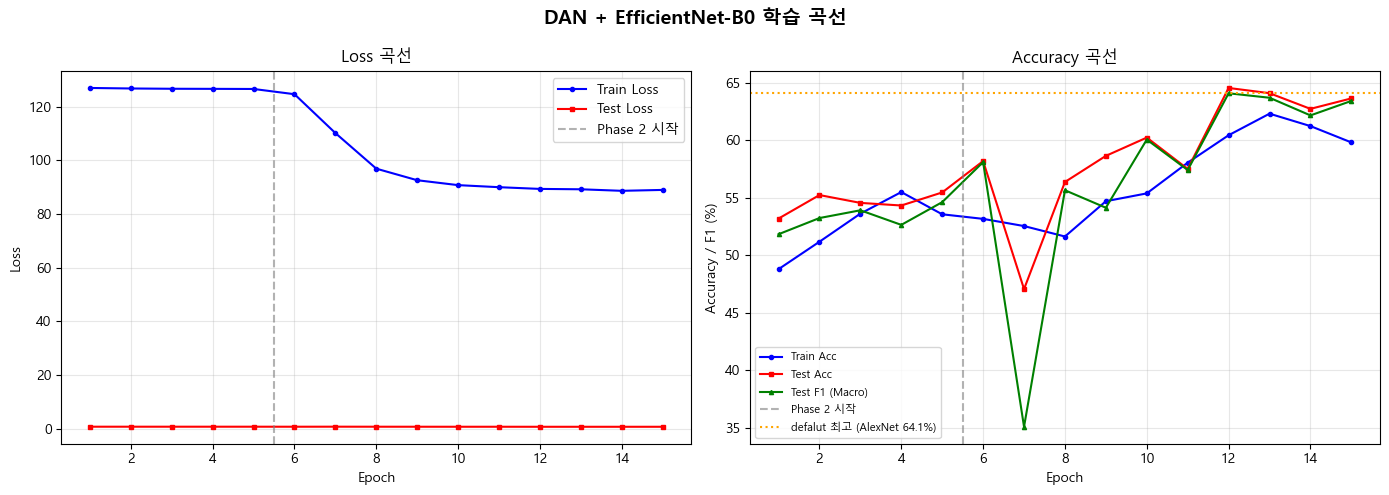

저장: viz_02_learning_curve.png


In [88]:
total_epochs = len(history['train_loss'])
ep_axis = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DAN + EfficientNet-B0 학습 곡선', fontsize=14, fontweight='bold')

# Loss 곡선
axes[0].plot(ep_axis, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
axes[0].plot(ep_axis, history['test_loss'],  'r-s', markersize=3, label='Test Loss')
axes[0].axvline(EPOCHS_1 + 0.5, color='gray', linestyle='--', alpha=0.6, label='Phase 2 시작')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss 곡선')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 곡선
axes[1].plot(ep_axis, history['train_acc'], 'b-o', markersize=3, label='Train Acc')
axes[1].plot(ep_axis, history['test_acc'],  'r-s', markersize=3, label='Test Acc')
axes[1].plot(ep_axis, history['test_f1'],   'g-^', markersize=3, label='Test F1 (Macro)')
axes[1].axvline(EPOCHS_1 + 0.5, color='gray', linestyle='--', alpha=0.6, label='Phase 2 시작')
axes[1].axhline(64.1, color='orange', linestyle=':', linewidth=1.5,
                label='defalut 최고 (AlexNet 64.1%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy / F1 (%)')
axes[1].set_title('Accuracy 곡선')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_02_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_02_learning_curve.png')

## Viz 3 — 전체 모델 Test Accuracy 비교

In [ ]:
# defalut_2 모델들 + 내 모델 비교
result_names  = ['SimpleCNN\nMaxPool', 'SimpleCNN\nAvgPool', 'SimpleCNN\n+Aug',
                 'AlexNet\nFine-tune', 'VGG16\nScratch', 'DAN+\nEff-B0\n(내 모델)']
result_accs   = [60.0, 60.0, 60.2, 64.1, 46.6, final_acc]
result_colors = ['#aec6cf', '#aec6cf', '#aec6cf', '#aec6cf', '#aec6cf', '#ff6b6b']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(result_names, result_accs,
              color=result_colors, edgecolor='white', linewidth=1.2, width=0.6)

for bar, val in zip(bars, result_accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.axhline(64.1, color='orange', linestyle='--', linewidth=1.5,
           label='defalut 최고 (AlexNet 64.1%)')
ax.set_ylim(0, max(result_accs) * 1.18)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('모델 Test Accuracy 비교 (defalut_2 vs 내 모델)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_03_test_acc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_03_test_acc_comparison.png')

## Viz 4 — Train-Test 갭 비교 (과적합 분석)

In [ ]:
# 과적합 비교 (defalut_2 모델들 + 내 모델)
gap_model_names = ['SimpleCNN\nMaxPool', 'SimpleCNN\n+Aug', 'AlexNet\nFine-tune',
                   'VGG16\nScratch', 'DAN+Eff-B0\n(내 모델)']
train_accs_list = [84.3, 91.4, 98.5, 46.5, history['train_acc'][-1]]
test_accs_list  = [60.0, 60.2, 64.1, 46.6, final_acc]
gaps_list       = [t - e for t, e in zip(train_accs_list, test_accs_list)]

x = np.arange(len(gap_model_names))
w = 0.32

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train-Test 갭 비교 (과적합 분석)', fontsize=14, fontweight='bold')

b1 = axes[0].bar(x - w/2, train_accs_list, w, label='Train Acc', color='steelblue', alpha=0.8)
b2 = axes[0].bar(x + w/2, test_accs_list,  w, label='Test Acc',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gap_model_names, fontsize=8)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}', ha='center', fontsize=7)

gap_colors = []
for g in gaps_list:
    if g > 20:
        gap_colors.append('#ff6b6b')
    elif g > 10:
        gap_colors.append('#ffd93d')
    else:
        gap_colors.append('#6bcb77')

bars2 = axes[1].bar(gap_model_names, gaps_list, color=gap_colors, edgecolor='white')
for bar, g in zip(bars2, gaps_list):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{g:.1f}%p', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(10, color='gray', linestyle='--', alpha=0.5, label='10%p 기준선')
axes[1].set_ylabel('Train - Test 갭 (%p)')
axes[1].set_title('과적합 정도 (낮을수록 좋음)\n초록<10  노랑10~20  빨강>20')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_04_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_04_overfitting_gap.png')

## Viz 5 — Confusion Matrix

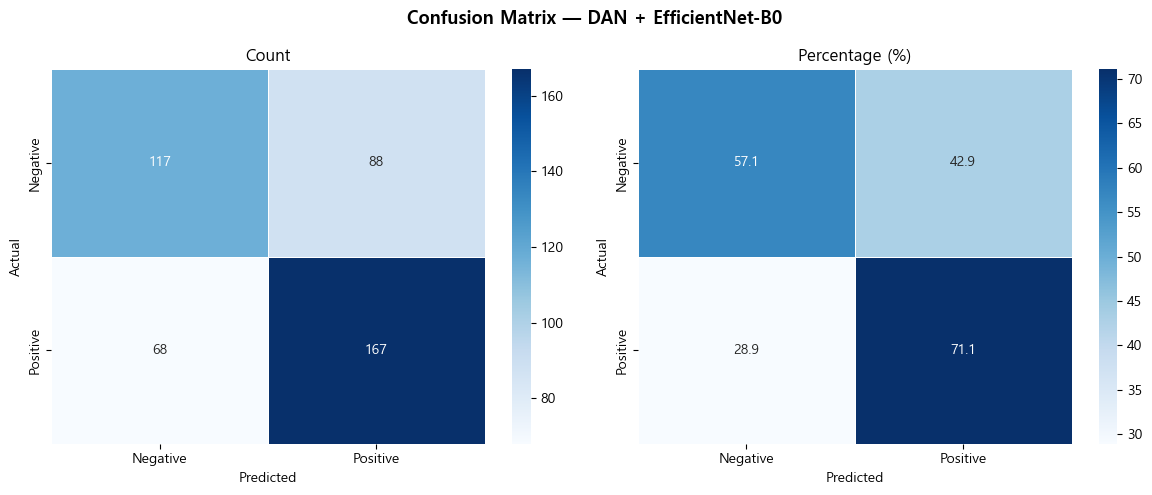

Precision (Pos) : 65.49%
Recall    (Pos) : 71.06%
저장: viz_05_confusion_matrix.png


In [91]:
cm_arr = confusion_matrix(final_labels, final_preds)
cm_pct = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — DAN + EfficientNet-B0', fontsize=13, fontweight='bold')

# Count
sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Count')

# Percentage
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Percentage (%)')

plt.tight_layout()
plt.savefig('viz_05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_arr.ravel()
print(f'Precision (Pos) : {tp/(tp+fp)*100:.2f}%')
print(f'Recall    (Pos) : {tp/(tp+fn)*100:.2f}%')
print('저장: viz_05_confusion_matrix.png')

## Viz 6 — DAN Attention Map 시각화

In [ ]:
def get_attention_maps(model, img_pil, device):
    model.eval()
    tensor = val_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        _, _, attn_maps = model(tensor)
    maps = attn_maps[0].cpu().numpy().reshape(4, 7, 7)
    return maps


def overlay_attention(img_pil, attn_map, alpha=0.5):
    attn_resized = cv2.resize(attn_map, (224, 224))
    min_val = attn_resized.min()
    max_val = attn_resized.max()
    attn_norm = (attn_resized - min_val) / (max_val - min_val + 1e-8)
    heat    = cm.jet(attn_norm)[:, :, :3]
    img_np  = np.array(img_pil).astype(float) / 255.0
    blended = (1 - alpha) * img_np + alpha * heat
    return (blended * 255).astype(np.uint8)


sample_count  = 4
sample_fnames = f_test[:sample_count]
sample_y      = y_test[:sample_count]
label_names   = {0: 'Negative', 1: 'Positive'}
head_names    = ['Head 1\n(이마/눈썹)', 'Head 2\n(눈/코)', 'Head 3\n(입/턱)', 'Head 4\n(전체맥락)']

fig, axes = plt.subplots(sample_count, 6, figsize=(18, sample_count * 3.2))
fig.suptitle('DAN Multi-head Attention Map 시각화\n(각 head가 주목하는 얼굴 부위)',
             fontsize=13, fontweight='bold')

for row in range(sample_count):
    fname = sample_fnames[row]
    label = sample_y[row]

    arr     = np.fromfile(os.path.join(IMAGE_FOLDER, fname), np.uint8)
    rgb     = cv2.cvtColor(cv2.imdecode(arr, cv2.IMREAD_COLOR), cv2.COLOR_RGB2BGR)
    rgb     = cv2.cvtColor(arr if False else cv2.imdecode(np.fromfile(os.path.join(IMAGE_FOLDER, fname), np.uint8), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    face_pil, _ = face_crop_mtcnn(Image.fromarray(rgb))
    face_pil = face_pil.resize((224, 224), Image.BILINEAR)

    attn_maps_np = get_attention_maps(model, face_pil, device)

    tensor = val_transform(face_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _, _ = model(tensor)
        pred = torch.argmax(logits, 1).item()

    axes[row, 0].imshow(np.array(face_pil))
    result_color = 'green' if pred == label else 'red'
    axes[row, 0].set_title(
        f'GT: {label_names[label]}\nPred: {label_names[pred]}',
        fontsize=9, color=result_color
    )
    axes[row, 0].axis('off')

    for col in range(4):
        overlaid = overlay_attention(face_pil, attn_maps_np[col])
        axes[row, col + 1].imshow(overlaid)
        axes[row, col + 1].set_title(head_names[col], fontsize=8)
        axes[row, col + 1].axis('off')

    mean_map = attn_maps_np.mean(axis=0)
    overlaid_mean = overlay_attention(face_pil, mean_map)
    axes[row, 5].imshow(overlaid_mean)
    axes[row, 5].set_title('평균 Attention', fontsize=8)
    axes[row, 5].axis('off')

plt.tight_layout()
plt.savefig('viz_06_attention_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_06_attention_map.png')

## Viz 7 — 예측 샘플 (정답 상위 4 / 오답 상위 4)

In [ ]:
model.eval()

all_results = []   # (true_label, pred_label, confidence, face_pil)

for i in range(len(f_test)):
    fname = f_test[i]
    label = y_test[i]

    arr     = np.fromfile(os.path.join(IMAGE_FOLDER, fname), np.uint8)
    rgb     = cv2.cvtColor(cv2.imdecode(arr, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    face_pil, _ = face_crop_mtcnn(Image.fromarray(rgb))
    face_pil = face_pil.resize((224, 224), Image.BILINEAR)

    tensor = val_transform(face_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _, _ = model(tensor)
        prob = torch.softmax(logits, 1)
        pred = torch.argmax(prob, 1).item()
        conf = prob[0, pred].item()

    all_results.append((label, pred, conf, face_pil))

# 정답 / 오답 분리
correct_list   = []
incorrect_list = []
for r in all_results:
    if r[0] == r[1]:
        correct_list.append(r)
    else:
        incorrect_list.append(r)

print(f'정답: {len(correct_list)}장  /  오답: {len(incorrect_list)}장')

# 신뢰도 내림차순 정렬 후 상위 4장
correct_sorted   = sorted(correct_list,   key=lambda r: r[2], reverse=True)[:4]
incorrect_sorted = sorted(incorrect_list, key=lambda r: r[2], reverse=True)[:4]

label_names = {0: 'Negative', 1: 'Positive'}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('예측 샘플  |  상단: 정답 (Confidence 상위4) / 하단: 오답 (상위4)',
             fontsize=12, fontweight='bold')

for col in range(4):
    lbl, pred, conf, face_pil = correct_sorted[col]
    axes[0, col].imshow(np.array(face_pil))
    axes[0, col].set_title(
        f'GT: {label_names[lbl]}\nPred: {label_names[pred]}\n({conf*100:.1f}%)',
        color='green', fontsize=9
    )
    axes[0, col].axis('off')

for col in range(4):
    lbl, pred, conf, face_pil = incorrect_sorted[col]
    axes[1, col].imshow(np.array(face_pil))
    axes[1, col].set_title(
        f'GT: {label_names[lbl]}\nPred: {label_names[pred]}\n({conf*100:.1f}%)',
        color='red', fontsize=9
    )
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('viz_07_prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_07_prediction_samples.png')

## Viz 8 — 전처리 비교 (Haar Cascade vs MTCNN)

In [ ]:
face_cascade_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def haar_crop(img_rgb):
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    faces = face_cascade_haar.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        crop = img_rgb[y:y+h, x:x+w]
        return cv2.resize(crop, (224, 224)), True
    return cv2.resize(img_rgb, (224, 224)), False


samples6 = f_test[:6]

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('전처리 비교: 원본 / Haar Cascade (defalut) / MTCNN (내 전처리)',
             fontsize=13, fontweight='bold')
row_labels = ['원본', 'defalut\n(Haar Cascade)', '내 전처리\n(MTCNN)']

for col in range(6):
    fname = samples6[col]
    arr   = np.fromfile(os.path.join(IMAGE_FOLDER, fname), np.uint8)
    rgb   = cv2.cvtColor(cv2.imdecode(arr, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    pil   = Image.fromarray(rgb)

    axes[0, col].imshow(cv2.resize(rgb, (224, 224)))
    axes[0, col].axis('off')

    haar_img, haar_det = haar_crop(rgb)
    axes[1, col].imshow(haar_img)
    axes[1, col].set_title('탐지 성공' if haar_det else '실패→원본반환',
                            fontsize=8, color='green' if haar_det else 'red')
    axes[1, col].axis('off')

    mtcnn_img, mtcnn_det = face_crop_mtcnn(pil)
    mtcnn_img = mtcnn_img.resize((224, 224), Image.BILINEAR)
    axes[2, col].imshow(np.array(mtcnn_img))
    axes[2, col].set_title('탐지+정렬' if mtcnn_det else 'fallback(중앙crop)',
                            fontsize=8, color='green')
    axes[2, col].axis('off')

for row in range(3):
    axes[row, 0].set_ylabel(row_labels[row], fontsize=10,
                             rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig('viz_08_preprocessing_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_08_preprocessing_compare.png')

## Viz 9 — Augmentation 효과 비교

In [ ]:
def aug_gaussian_noise_def(img, std=0.03):
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    return np.clip(img + noise, 0.0, 1.0)


def aug_salt_pepper_def(img, amount=0.02):
    noisy = img.copy()
    n     = int(amount * img.size / 2)
    coords_s = [np.random.randint(0, i, n) for i in img.shape[:2]]
    noisy[coords_s[0], coords_s[1]] = 1.0
    coords_p = [np.random.randint(0, i, n) for i in img.shape[:2]]
    noisy[coords_p[0], coords_p[1]] = 0.0
    return noisy


def denormalize(tensor):
    t = tensor.clone().cpu()
    for c in range(3):
        t[c] = t[c] * STD[c] + MEAN[c]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


arr0     = np.fromfile(os.path.join(IMAGE_FOLDER, f_test[0]), np.uint8)
rgb0     = cv2.cvtColor(cv2.imdecode(arr0, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
face_pil0, _ = face_crop_mtcnn(Image.fromarray(rgb0))
face_pil0 = face_pil0.resize((224, 224), Image.BILINEAR)
face_np0 = np.array(face_pil0).astype(np.float32) / 255.0

aug_rotation = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
aug_shift = transforms.Compose([
    transforms.RandomAffine(0, translate=(0.15, 0.15)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
aug_colorjitter = transforms.Compose([
    transforms.ColorJitter(0.4, 0.4, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
aug_erasing = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=1.0, scale=(0.05, 0.15))
])

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle('Augmentation 비교 (같은 이미지에 적용)', fontsize=12, fontweight='bold')

axes[0].imshow(np.clip(face_np0, 0, 1))
axes[0].set_title('원본', fontsize=8)
axes[0].axis('off')

axes[1].imshow(np.clip(aug_gaussian_noise_def(face_np0), 0, 1))
axes[1].set_title('defalut\nGaussian', fontsize=8, color='#888888')
axes[1].axis('off')

axes[2].imshow(np.clip(aug_salt_pepper_def(face_np0), 0, 1))
axes[2].set_title('defalut\nSalt&Pepper', fontsize=8, color='#888888')
axes[2].axis('off')

axes[3].imshow(np.clip(denormalize(aug_rotation(face_pil0)), 0, 1))
axes[3].set_title('내 전처리\nRotation', fontsize=8, color='#ff6b6b')
axes[3].axis('off')

axes[4].imshow(np.clip(denormalize(aug_shift(face_pil0)), 0, 1))
axes[4].set_title('내 전처리\nShift', fontsize=8, color='#ff6b6b')
axes[4].axis('off')

axes[5].imshow(np.clip(denormalize(aug_colorjitter(face_pil0)), 0, 1))
axes[5].set_title('내 전처리\nColorJitter', fontsize=8, color='#ff6b6b')
axes[5].axis('off')

axes[6].imshow(np.clip(denormalize(aug_erasing(face_pil0)), 0, 1))
axes[6].set_title('내 전처리\nRandom Erasing', fontsize=8, color='#ff6b6b')
axes[6].axis('off')

axes[7].imshow(np.clip(denormalize(train_transform(face_pil0)), 0, 1))
axes[7].set_title('내 전처리\n복합 적용', fontsize=8, color='#ff6b6b')
axes[7].axis('off')

plt.tight_layout()
plt.savefig('viz_09_augmentation_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_09_augmentation_compare.png')

## Viz 10 — 최종 성능 요약 테이블

In [ ]:
summary_data = [
    ['SimpleCNN (MaxPool)',  '84.3', '60.0', '24.3', 'defalut_2 / 직접 구현'],
    ['SimpleCNN (+Aug)',     '91.4', '60.2', '31.2', 'defalut_2 / Gaussian+SP'],
    ['AlexNet fine-tune',   '98.5', '64.1', '34.4', 'defalut_2 / ImageNet pretrain'],
    ['VGG16 scratch',       '46.5', '46.6',  '0.1', 'defalut_2 / 학습 불안정'],
    ['DAN + EfficientNet-B0',
     f'{history["train_acc"][-1]:.1f}',
     f'{final_acc:.1f}',
     f'{history["train_acc"][-1] - final_acc:.1f}',
     '내 모델 / Multi-head Attention'],
]

col_labels = ['모델', 'Train Acc (%)', 'Test Acc (%)', '갭 (%p)', '특징']

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')

table = ax.table(
    cellText=summary_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.9)

# 헤더
for col in range(len(col_labels)):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')

# defalut_2 행
for row in range(1, 5):
    for col in range(len(col_labels)):
        table[row, col].set_facecolor('#eaf4fb')

# 내 모델 강조
for col in range(len(col_labels)):
    table[5, col].set_facecolor('#ffe0e0')
    table[5, col].set_text_props(fontweight='bold')

ax.set_title('전체 모델 성능 요약 (defalut_2 vs 내 모델)', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('viz_10_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: viz_10_summary_table.png')

## Viz 11 — 클래스별 신뢰도 분포

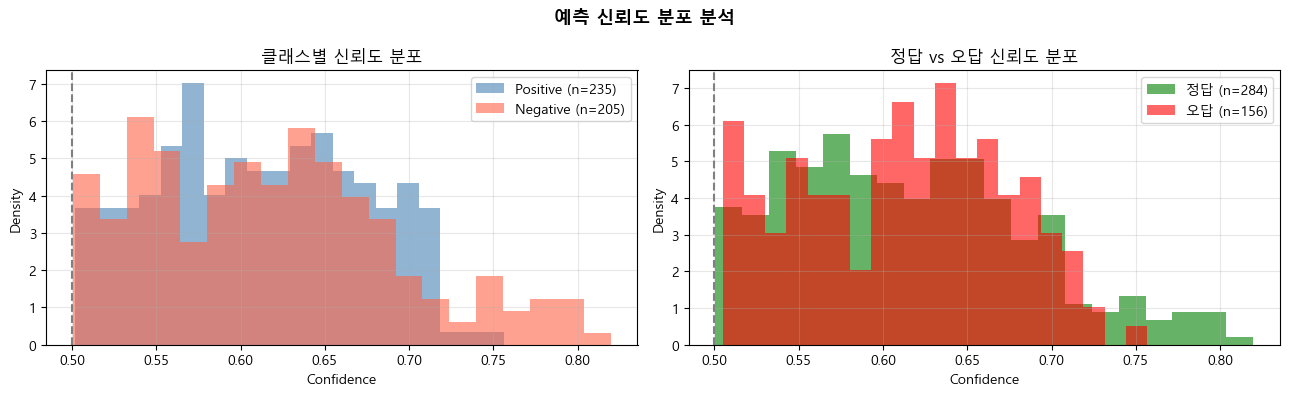

정답 평균 신뢰도 : 61.6%
오답 평균 신뢰도 : 61.2%
저장: viz_11_confidence_dist.png


In [97]:
model.eval()

pos_confs     = []
neg_confs     = []
correct_confs = []
wrong_confs   = []

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(device)

        logits, _, _ = model(batch_imgs)
        probs = torch.softmax(logits, 1).cpu()
        preds = torch.argmax(probs, 1)

        for i in range(len(batch_labels)):
            label = batch_labels[i].item()
            pred  = preds[i].item()
            conf  = probs[i, pred].item()

            if label == 1:
                pos_confs.append(conf)
            else:
                neg_confs.append(conf)

            if pred == label:
                correct_confs.append(conf)
            else:
                wrong_confs.append(conf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('예측 신뢰도 분포 분석', fontsize=13, fontweight='bold')

# 클래스별 분포
axes[0].hist(pos_confs, bins=20, alpha=0.6, color='steelblue',
             label=f'Positive (n={len(pos_confs)})', density=True)
axes[0].hist(neg_confs, bins=20, alpha=0.6, color='tomato',
             label=f'Negative (n={len(neg_confs)})', density=True)
axes[0].axvline(0.5, color='gray', linestyle='--')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Density')
axes[0].set_title('클래스별 신뢰도 분포')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 정답/오답별 분포
axes[1].hist(correct_confs, bins=20, alpha=0.6, color='green',
             label=f'정답 (n={len(correct_confs)})', density=True)
axes[1].hist(wrong_confs, bins=20, alpha=0.6, color='red',
             label=f'오답 (n={len(wrong_confs)})', density=True)
axes[1].axvline(0.5, color='gray', linestyle='--')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Density')
axes[1].set_title('정답 vs 오답 신뢰도 분포')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_11_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'정답 평균 신뢰도 : {np.mean(correct_confs)*100:.1f}%')
print(f'오답 평균 신뢰도 : {np.mean(wrong_confs)*100:.1f}%')
print('저장: viz_11_confidence_dist.png')

---
## 저장된 시각화 파일 목록

In [98]:
viz_files = sorted(glob.glob('viz_*.png'))
print(f'저장된 시각화 파일: {len(viz_files)}개')
for f in viz_files:
    size = os.path.getsize(f) / 1024
    print(f'  {f}  ({size:.0f} KB)')

print()
print('=========================================')
print(f'  최종 Test Accuracy : {final_acc:.2f}%')
print(f'  defalut AlexNet   : 64.1%')
if final_acc > 64.1:
    print(f'  목표 달성! +{final_acc - 64.1:.2f}%p 향상')
else:
    print(f'  차이: {final_acc - 64.1:.2f}%p')
print('=========================================')

저장된 시각화 파일: 11개
  viz_01_params.png  (66 KB)
  viz_02_learning_curve.png  (119 KB)
  viz_03_test_acc_comparison.png  (70 KB)
  viz_04_overfitting_gap.png  (104 KB)
  viz_05_confusion_matrix.png  (55 KB)
  viz_06_attention_map.png  (1273 KB)
  viz_07_prediction_samples.png  (1151 KB)
  viz_08_preprocessing_compare.png  (2458 KB)
  viz_09_augmentation_compare.png  (1095 KB)
  viz_10_summary_table.png  (102 KB)
  viz_11_confidence_dist.png  (49 KB)

  최종 Test Accuracy : 64.55%
  defalut AlexNet   : 64.1%
  목표 달성! +0.45%p 향상
